# Predicting Federal Reserve Rate-Hike Probabilities from the U.S. Treasury Yield Curve

## Objective

Use U.S. Treasury yields at several maturities to estimate the probability of a Federal Reserve interest-rate hike for the remaining 2026 decision months: **September, October, November, and December**.

Treasury maturities used:
- 3-month Treasury
- 6-month Treasury
- 10-year Treasury
- 30-year Treasury

The forecast information set is frozen at **September 10, 2026** so the notebook remains reproducible if it is rerun later. The scheduled 2026 FOMC decision dates relevant to this assignment are **September 16, October 28, and December 9**. There is **no regularly scheduled FOMC meeting in November 2026**.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, brier_score_loss
from pandas_datareader import data as web
# Create the output folder for figures when the notebook is run
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


## 1. Download the Data

The analysis uses Federal Reserve Economic Data (FRED). `DFF` is the effective federal funds rate and the other series are constant-maturity Treasury yields.

In [2]:
start = "2006-02-10"
forecast_date = pd.Timestamp("2026-09-10")

series = {
    "DGS3MO": "3M",
    "DGS6MO": "6M",
    "DGS10": "10Y",
    "DGS30": "30Y",
    "DFF": "FedFunds"
}

df = web.DataReader(list(series.keys()), "fred", start, forecast_date)
df = df.rename(columns=series)
df = df.apply(pd.to_numeric, errors="coerce")

# FRED Treasury series are not reported on weekends/holidays.
# Forward-fill so calendar-day shifts below correspond to actual calendar days.
df = df.ffill().dropna()

print("First observation:", df.index.min().date())
print("Last observation: ", df.index.max().date())
print(df.tail())

First observation: 2006-02-10
Last observation:  2026-09-10
              3M    6M   10Y   30Y  FedFunds
DATE                                        
2026-09-06  3.91  3.98  4.78  5.24      3.63
2026-09-07  3.91  3.98  4.78  5.24      3.63
2026-09-08  3.94  4.00  4.80  5.25      3.63
2026-09-09  3.95  4.01  4.83  5.28      3.63
2026-09-10  4.00  4.07  4.95  5.37      3.63


/var/folders/x9/fxz0_3x94n93xcvzgtjyjgl00000gn/T/ipykernel_41146/3560672103.py:12: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df = web.DataReader(list(series.keys()), "fred", start, forecast_date)


## 2. Current Yield Curve and Predictor Construction

The raw Treasury yields are included directly, along with curve spreads and gaps relative to the effective federal funds rate. Short-maturity yields are particularly informative about near-term policy expectations, while longer maturities also reflect inflation, growth, supply, and term-premium effects.

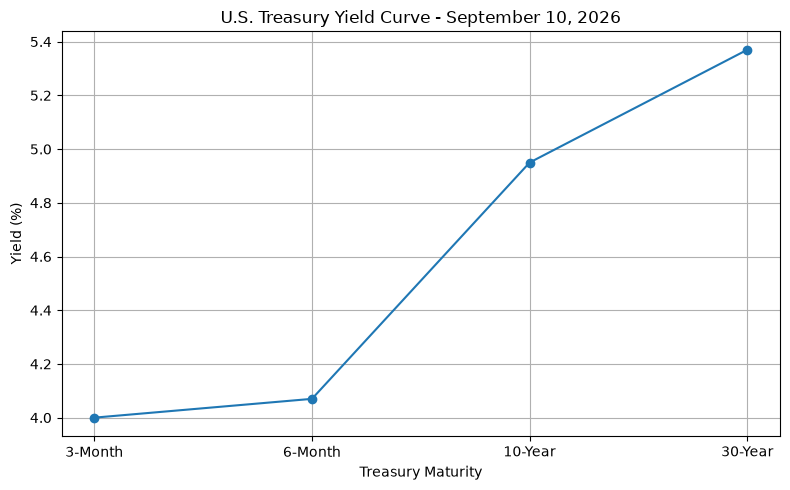

3M     4.00
6M     4.07
10Y    4.95
30Y    5.37
Name: 2026-09-10 00:00:00, dtype: float64


In [3]:
latest_date = df.index[-1]
current_yields = df.loc[latest_date, ["3M", "6M", "10Y", "30Y"]]

maturities = ["3-Month", "6-Month", "10-Year", "30-Year"]
plt.figure(figsize=(8, 5))
plt.plot(maturities, current_yields.values, marker="o")
plt.xlabel("Treasury Maturity")
plt.ylabel("Yield (%)")
plt.title(f"U.S. Treasury Yield Curve - {latest_date.strftime('%B %d, %Y')}")
plt.grid(True)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "treasury_yield_curve.png", dpi=300, bbox_inches="tight")
plt.show()

print(current_yields)

In [4]:
df["spread_6m_3m"] = df["6M"] - df["3M"]
df["spread_10y_3m"] = df["10Y"] - df["3M"]
df["spread_30y_3m"] = df["30Y"] - df["3M"]
df["spread_10y_6m"] = df["10Y"] - df["6M"]
df["spread_30y_10y"] = df["30Y"] - df["10Y"]
df["gap_3m_ff"] = df["3M"] - df["FedFunds"]
df["gap_6m_ff"] = df["6M"] - df["FedFunds"]

features = [
    "3M", "6M", "10Y", "30Y",
    "spread_6m_3m", "spread_10y_3m", "spread_30y_3m",
    "gap_3m_ff", "gap_6m_ff"
]

print("Predictors:")
for f in features:
    print("-", f)

Predictors:
- 3M
- 6M
- 10Y
- 30Y
- spread_6m_3m
- spread_10y_3m
- spread_30y_3m
- gap_3m_ff
- gap_6m_ff


## 3. Align the Targets to the 2026 FOMC Decision Dates


This file uses the actual number of calendar days from the September 10 information date to each scheduled decision date:

- September 16: current date → September decision
- October 28: September decision → October decision
- December 9: October decision → December decision

A hike is defined as an increase of at least **20 basis points** in the effective federal funds rate during the relevant interval. The 20-basis-point threshold allows a normal 25-basis-point policy move to be detected despite small day-to-day variation in the effective rate.

This makes October and December **incremental meeting-window estimates**, rather than cumulative probabilities that can count an earlier hike.

In [5]:
meeting_dates = {
    "September": pd.Timestamp("2026-09-16"),
    "October": pd.Timestamp("2026-10-28"),
    "December": pd.Timestamp("2026-12-09")
}

sep_days = (meeting_dates["September"] - forecast_date).days
oct_days = (meeting_dates["October"] - forecast_date).days
dec_days = (meeting_dates["December"] - forecast_date).days

print("Calendar days from forecast date:")
print("September decision:", sep_days)
print("October decision:  ", oct_days)
print("December decision: ", dec_days)

# Federal funds rate at the relative future decision horizons
df["ff_sep_horizon"] = df["FedFunds"].shift(-sep_days)
df["ff_oct_horizon"] = df["FedFunds"].shift(-oct_days)
df["ff_dec_horizon"] = df["FedFunds"].shift(-dec_days)

# Incremental changes for each meeting window
df["change_sep_window"] = df["ff_sep_horizon"] - df["FedFunds"]
df["change_oct_window"] = df["ff_oct_horizon"] - df["ff_sep_horizon"]
df["change_dec_window"] = df["ff_dec_horizon"] - df["ff_oct_horizon"]

def make_binary_target(change_series, threshold=0.20):
    return np.where(
        change_series.notna(),
        (change_series >= threshold).astype(int),
        np.nan
    )

df["hike_sep"] = make_binary_target(df["change_sep_window"])
df["hike_oct"] = make_binary_target(df["change_oct_window"])
df["hike_dec"] = make_binary_target(df["change_dec_window"])

print("\nTarget counts:")
for target in ["hike_sep", "hike_oct", "hike_dec"]:
    print(f"\n{target}")
    print(df[target].value_counts(dropna=False))

Calendar days from forecast date:
September decision: 6
October decision:   48
December decision:  90

Target counts:

hike_sep
hike_sep
0.0    7350
1.0     162
NaN       6
Name: count, dtype: int64

hike_oct
hike_oct
0.0    6579
1.0     891
NaN      48
Name: count, dtype: int64

hike_dec
hike_dec
0.0    6571
1.0     857
NaN      90
Name: count, dtype: int64


### Interpretation of the Historical Labels

The historical training labels use **relative windows with the same lengths as the 2026 meeting intervals**. They are therefore statistical analogues of the upcoming decision windows rather than a reconstruction of every historical FOMC calendar. This is still an approximation, but it is better aligned with the assignment than cumulative arbitrary horizons.

## 4. Train and Evaluate Logistic-Regression Models

A chronological split is used: observations before **January 1, 2020** are used for training, and observations from 2020 onward are used for out-of-sample evaluation. A time-ordered split is appropriate for forecasting because it avoids training on future observations.

The final models are **unweighted logistic regressions**. Since the goal is to estimate probabilities, probability calibration matters. Brier score is therefore emphasized along with ROC-AUC and accuracy.

In [6]:
def train_meeting_window_model(target, label):
    model_data = df[features + [target]].dropna()

    train = model_data[model_data.index < "2020-01-01"]
    test = model_data[model_data.index >= "2020-01-01"]

    X_train = train[features]
    y_train = train[target].astype(int)
    X_test = test[features]
    y_test = test[target].astype(int)

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(max_iter=1000))
    ])
    model.fit(X_train, y_train)

    probs = model.predict_proba(X_test)[:, 1]
    preds = model.predict(X_test)

    accuracy = accuracy_score(y_test, preds)
    brier = brier_score_loss(y_test, probs)
    auc = roc_auc_score(y_test, probs) if y_test.nunique() > 1 else np.nan

    metrics = {
        "Window": label,
        "Train observations": len(train),
        "Test observations": len(test),
        "Accuracy": accuracy,
        "ROC-AUC": auc,
        "Brier score": brier
    }
    return model, metrics

model_sep, metrics_sep = train_meeting_window_model(
    "hike_sep", f"Now to September ({sep_days} days)"
)
model_oct, metrics_oct = train_meeting_window_model(
    "hike_oct", f"September to October ({oct_days - sep_days} days)"
)
model_dec, metrics_dec = train_meeting_window_model(
    "hike_dec", f"October to December ({dec_days - oct_days} days)"
)

metrics_table = pd.DataFrame([metrics_sep, metrics_oct, metrics_dec])
metrics_table

,Window,Train observations,Test observations,Accuracy,ROC-AUC,Brier score
0,Now to September (6 days),5073,2439,0.932759,0.914965,0.048083
1,September to October (42 days),5073,2397,0.921569,0.977711,0.058984
2,October to December (42 days),5073,2355,0.898938,0.936332,0.078508


## 5. Estimate the 2026 Meeting-Window Probabilities

Each model uses the same Treasury-yield information available on September 10, 2026, but a different future outcome window. November is reported as 0% **only for a regularly scheduled meeting**, because the published 2026 FOMC calendar contains no November meeting.

In [7]:
current = df.loc[[forecast_date], features]

p_sep = model_sep.predict_proba(current)[0, 1]
p_oct = model_oct.predict_proba(current)[0, 1]
p_dec = model_dec.predict_proba(current)[0, 1]
p_nov = np.nan

results = pd.DataFrame({
    "Month": ["September", "October", "November", "December"],
    "Scheduled decision date": [
        "2026-09-16",
        "2026-10-28",
        "No scheduled meeting",
        "2026-12-09"
    ],
    "Estimated hike probability": [p_sep, p_oct, p_nov, p_dec],
    "Interpretation": [
        "Hike between Sep. 10 and Sep. 16",
        "Incremental hike after Sep. decision and by Oct. 28",
        "No regularly scheduled FOMC decision",
        "Incremental hike after Oct. decision and by Dec. 9"
    ]
})

results["Probability (%)"] = (
    results["Estimated hike probability"] * 100
).round(2)

# Display November as N/A because there is no regularly scheduled FOMC meeting.
results["Probability display"] = results["Probability (%)"].apply(
    lambda x: "N/A" if pd.isna(x) else f"{x:.2f}%"
)

results[["Month", "Scheduled decision date", "Probability display", "Interpretation"]]

,Month,Scheduled decision date,Probability display,Interpretation
0,September,2026-09-16,3.09%,Hike between Sep. 10 and Sep. 16
1,October,2026-10-28,57.47%,Incremental hike after Sep. decision and by Oc...
2,November,No scheduled meeting,N/A,No regularly scheduled FOMC decision
3,December,2026-12-09,2.02%,Incremental hike after Oct. decision and by De...


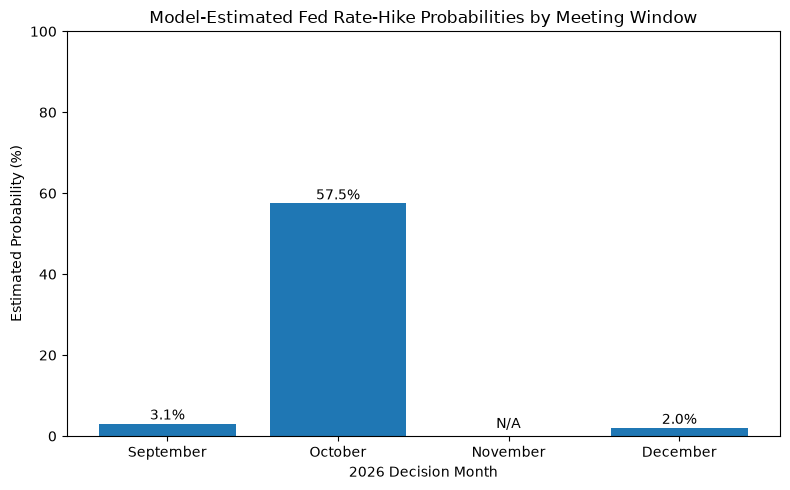

In [8]:
months = results["Month"]
probabilities = results["Estimated hike probability"] * 100

# Plot November at zero height only for visualization; label it N/A.
plot_probabilities = probabilities.fillna(0)

plt.figure(figsize=(8, 5))
bars = plt.bar(months, plot_probabilities)
plt.ylabel("Estimated Probability (%)")
plt.xlabel("2026 Decision Month")
plt.title("Model-Estimated Fed Rate-Hike Probabilities by Meeting Window")
plt.ylim(0, 100)

for month, bar, probability in zip(months, bars, probabilities):
    if pd.isna(probability):
        label = "N/A"
        y = 2
    else:
        label = f"{probability:.1f}%"
        y = min(bar.get_height() + 1, 98)

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        y,
        label,
        ha="center"
    )

plt.tight_layout()
plt.savefig(FIGURE_DIR / "fed_hike_probabilities.png", dpi=300, bbox_inches="tight")
plt.show()


## 6. Current Yield-Curve Interpretation

The short end of the Treasury curve is most directly related to near-term monetary-policy expectations, while 10-year and 30-year yields also contain information about inflation expectations, long-run growth, Treasury supply, risk premia, and term premia.

The model therefore uses both the level of yields and relative spreads. A positive 6-month-minus-3-month spread, for example, can be informative about how short-term rates are expected to evolve, but it should **not** be interpreted as a direct market-implied probability of a Fed hike.

In [9]:
yield_summary = pd.Series({
    "3-month yield": df.loc[forecast_date, "3M"],
    "6-month yield": df.loc[forecast_date, "6M"],
    "10-year yield": df.loc[forecast_date, "10Y"],
    "30-year yield": df.loc[forecast_date, "30Y"],
    "6M - 3M spread": df.loc[forecast_date, "spread_6m_3m"],
    "10Y - 3M spread": df.loc[forecast_date, "spread_10y_3m"],
    "30Y - 3M spread": df.loc[forecast_date, "spread_30y_3m"]
})

yield_summary

3-month yield      4.00
6-month yield      4.07
10-year yield      4.95
30-year yield      5.37
6M - 3M spread     0.07
10Y - 3M spread    0.95
30Y - 3M spread    1.37
dtype: float64

## 7. Limitations

1. **These are model-based probabilities, not Fed-funds-futures probabilities.** The model estimates historical statistical relationships between Treasury yields and subsequent changes in the effective federal funds rate.

2. **Historical labels are relative-window analogues.** The training labels use windows with the same lengths as the 2026 decision intervals rather than matching every historical FOMC meeting date.

3. **Treasury yields are not pure policy expectations.** Longer maturities also reflect inflation, growth, Treasury supply, risk premiums, and term premiums.

4. **Important macroeconomic variables are omitted.** The FOMC also considers inflation, employment, wages, GDP growth, financial conditions, and other incoming data.

5. **Relationships can change across monetary-policy regimes.** A model trained on 2006-2019 data may not behave identically in a later regime.

6. **Daily observations are serially correlated.** Consecutive yield observations are not independent, so strong out-of-sample scores should not be interpreted as causal evidence.

7. **November's 0% applies only to a scheduled meeting.** An unscheduled intermeeting action is theoretically possible but is outside the scope of this assignment.

- **November 2026 is reported as N/A, not 0%.** There is no regularly scheduled
  FOMC meeting in November. The analysis does not attempt to estimate the
  probability of an unscheduled intermeeting policy action.


## Conclusion

This notebook uses the **3-month, 6-month, 10-year, and 30-year Treasury yields**, yield-curve spreads, and gaps relative to the effective federal funds rate to estimate the probability of Federal Reserve tightening around the remaining 2026 decision windows.

The key methodological correction is that the targets now line up with the actual **September 16, October 28, and December 9** decision dates. The October and December probabilities are estimated for their **incremental intervals**, so an earlier hike is not automatically counted again as a later-meeting hike.

After running the notebook, the final results table above provides model-estimated probabilities for the scheduled September, October, and December 2026 decision windows. November is shown as N/A because there is no regularly scheduled FOMC meeting in that month. These should be interpreted as statistical forecasts based on Treasury-yield information, not as exact market prices or guarantees of Federal Reserve action.

## Data Sources

- **Federal Reserve Economic Data (FRED), Federal Reserve Bank of St. Louis**
  - `DGS3MO`: 3-Month Treasury Constant Maturity Rate
  - `DGS6MO`: 6-Month Treasury Constant Maturity Rate
  - `DGS10`: 10-Year Treasury Constant Maturity Rate
  - `DGS30`: 30-Year Treasury Constant Maturity Rate
  - `DFF`: Effective Federal Funds Rate
  - https://fred.stlouisfed.org/

- **Board of Governors of the Federal Reserve System**
  - 2026 FOMC meeting calendar
  - https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm

### Reproducibility Note

The forecast information set is intentionally fixed at **September 10, 2026**. This prevents later reruns from changing the assignment's prediction date and makes the horizon calculations reproducible.